<h1 style="text-align: center; font-weight: bold;">Module-04</h1>
<h3 style="text-align: center;">Data Bias in Housing</h3>
<h3 style="text-align: center;">DATA-6550</h3>

<h4 style="text-align: center; line-height: 1.5;">By<br><b>Richard Hoehn</b></h4>

<hr style="height:10px; border:0px; background: linear-gradient(to right, white, blue, white); margin:50px;">

# Import Libraries & Setup Constants

In [4]:
# Imports of main Libs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Chi-Square Test
from scipy.stats import chi2_contingency

# Handle Warnings
import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

#style options
%matplotlib inline

# Main Settings for Panda Display & Plotting Colors
pd.set_option('display.max_columns', 500) # Allows for up to 500 columns to be displayed when viewing a dataframe
plt.style.use('seaborn-v0_8') # A style that can be used for plots

# Constants - General Use
RND   = 42  # Randome Init
STARS = 50  # Sapcer for comments

In [5]:
# 01 - Load Data
df = pd.read_csv("../../Data/mortgage_covenant_data.csv")

# 02 - Display
display(df)

,activity_year,census_tract,derived_race,action_taken,loan_amount,property_value,income,interest_rate,tract_minority_population_percent,tract_to_msa_income_percentage,denial_reason-1,covenant_count,was_approved,covenant_density
0,2023,2.703706e+10,Race Not Available,6,185000.0,195000.0,NaN,6.125,40.37,73.48,10,0.0,False,NaN
1,2023,2.714103e+10,Race Not Available,6,375000.0,385000.0,NaN,6.625,10.64,121.26,10,0.0,False,NaN
2,2023,2.702395e+10,Race Not Available,6,105000.0,105000.0,NaN,6.125,8.92,90.13,10,0.0,False,NaN
3,2023,2.717110e+10,Race Not Available,6,285000.0,285000.0,NaN,6.750,13.27,104.37,10,0.0,False,NaN
4,2023,2.715948e+10,Race Not Available,6,175000.0,175000.0,NaN,6.875,5.87,82.22,10,0.0,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100926,2023,2.700902e+10,Race Not Available,6,255000.0,265000.0,NaN,6.125,4.88,106.18,10,0.0,False,NaN
100927,2023,2.706778e+10,Race Not Available,6,185000.0,335000.0,NaN,6.125,46.58,74.68,10,0.0,False,NaN
100928,2023,2.714948e+10,Race Not Available,6,65000.0,75000.0,NaN,6.750,20.14,118.83,10,0.0,False,NaN
100929,2023,2.705913e+10,Race Not Available,6,545000.0,525000.0,NaN,5.000,6.84,90.07,10,0.0,False,NaN


## 1: Approval Rates by Race  
This bar chart compares the average approval rates for loan applications across different racial groups. It highlights potential disparities in housing loan approvals based on race.


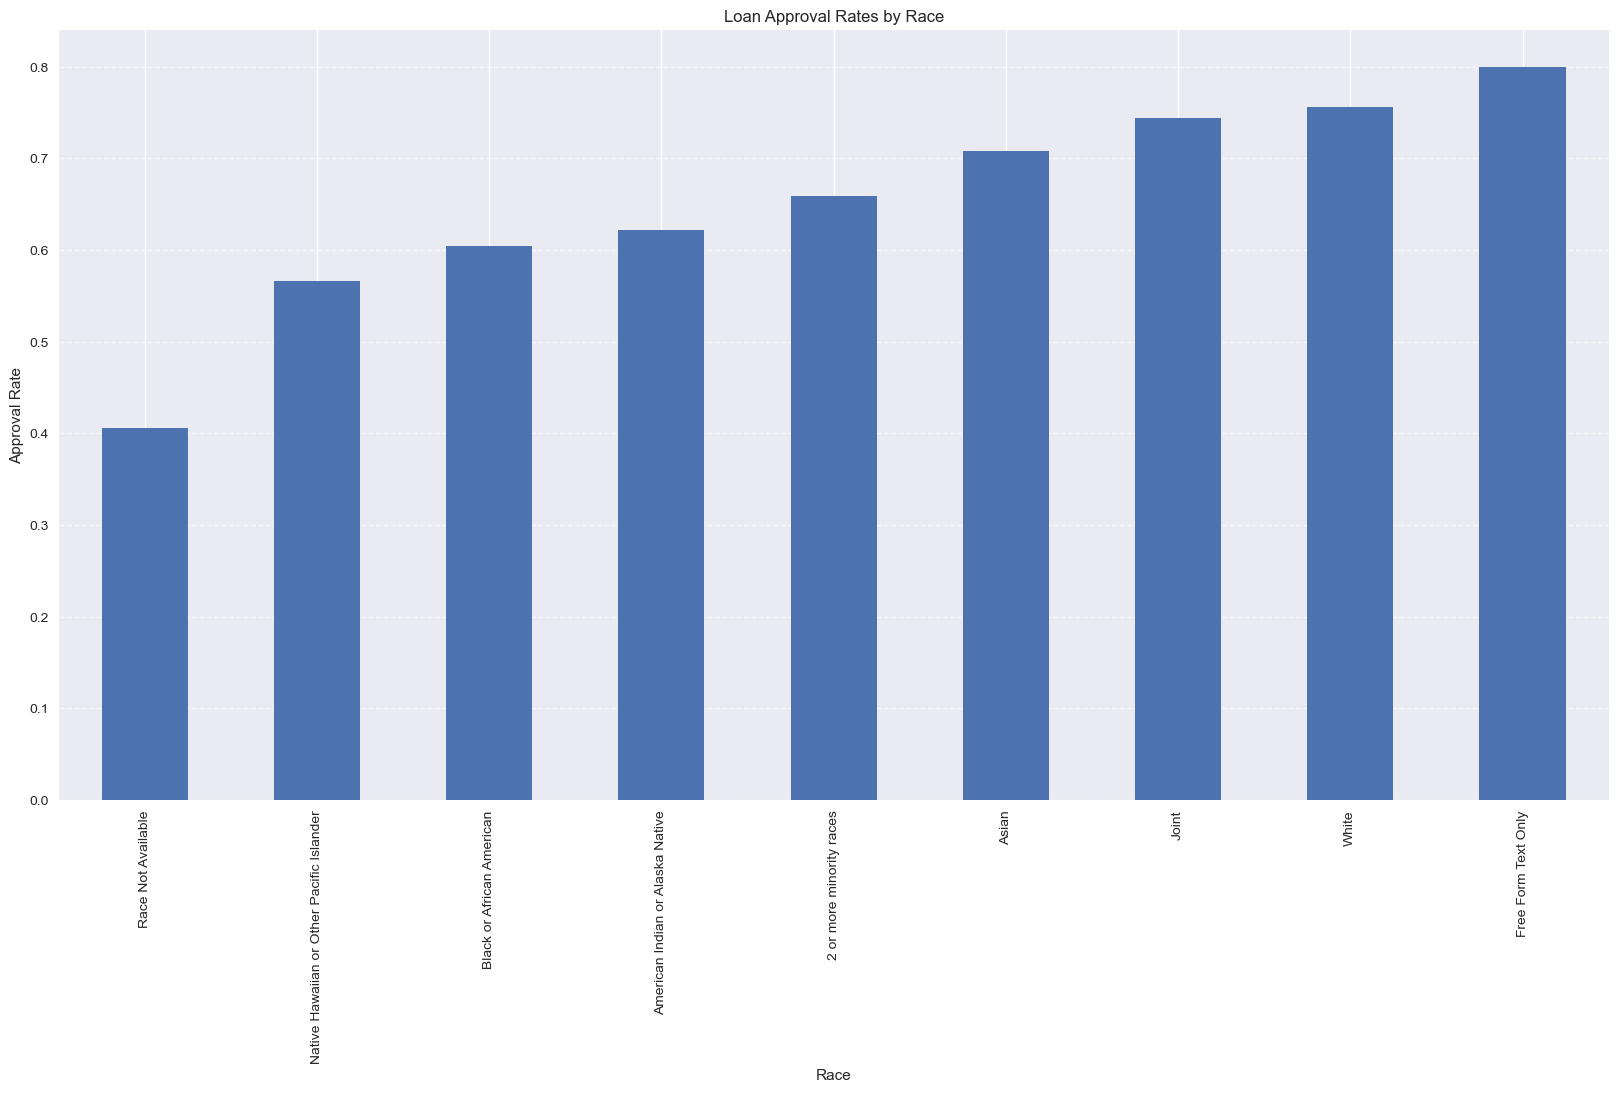

In [7]:
# 01 - Build DF
approval_rates = df.groupby('derived_race')['was_approved'].mean().sort_values()

approval_rates.plot(kind='bar', figsize=(20, 10))
plt.title('Loan Approval Rates by Race')
plt.xlabel('Race')
plt.ylabel('Approval Rate')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


## 2: Denial Reasons Distribution by Race  
This visualization presents the frequency of loan denial reasons broken down by racial categories. It identifies common denial reasons disproportionately affecting specific racial groups.


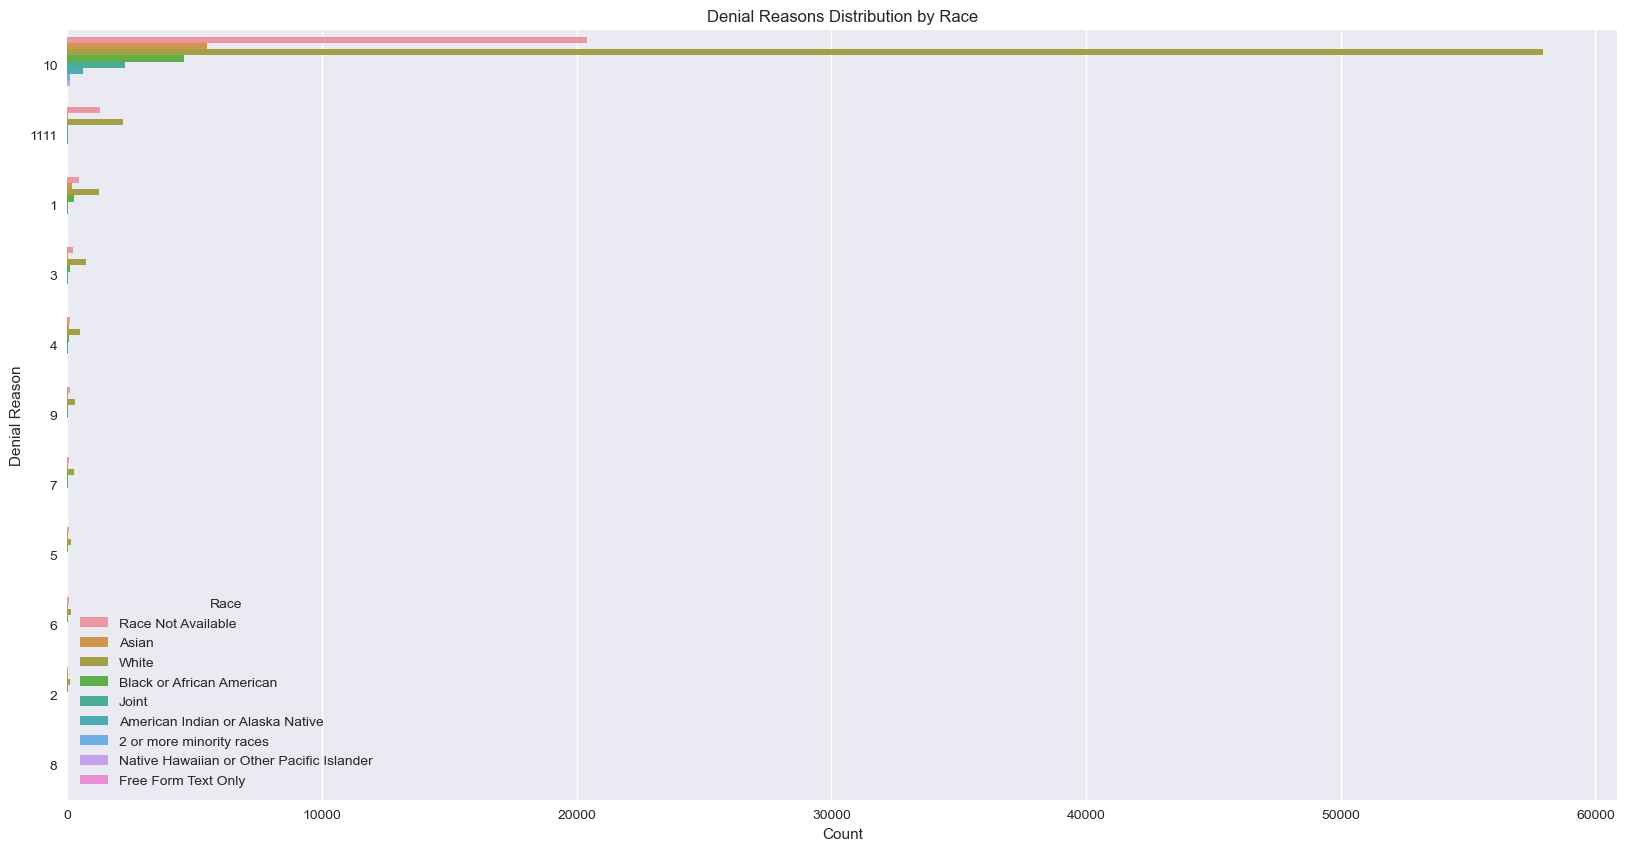

In [9]:
# 01 - Setup DF for Denails
plt.figure(figsize=(20,10))
sns.countplot(y='denial_reason-1', hue='derived_race', data=df, order=df['denial_reason-1'].value_counts().index)
plt.title('Denial Reasons Distribution by Race')
plt.xlabel('Count')
plt.ylabel('Denial Reason')
plt.legend(title='Race')
plt.show()


## 3: Interest Rates by Race  
The boxplot shows the distribution of loan interest rates offered to applicants across different races. It allows identification of patterns or biases in interest rate assignment.


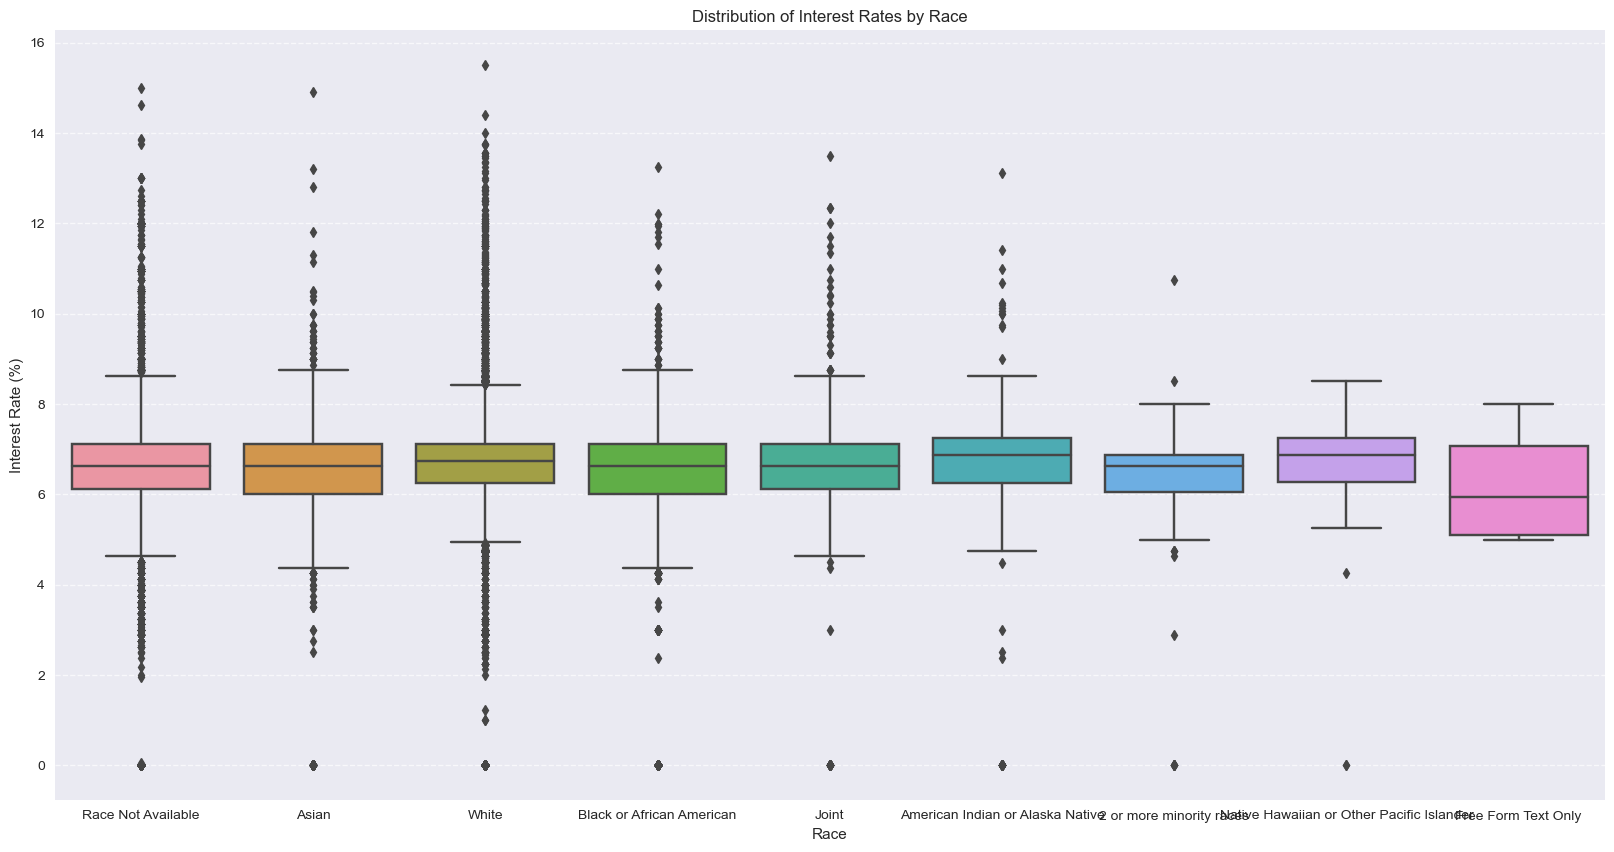

In [11]:
plt.figure(figsize=(20, 10))
sns.boxplot(x='derived_race', y='interest_rate', data=df)
plt.title('Distribution of Interest Rates by Race')
plt.xlabel('Race')
plt.ylabel('Interest Rate (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


## 4: Income vs. Loan Amount by Race and Approval Status  
This scatterplot visualizes the relationship between applicant income and requested loan amounts, categorized by race and approval status. It highlights any racial disparities in income-to-loan approval ratios.

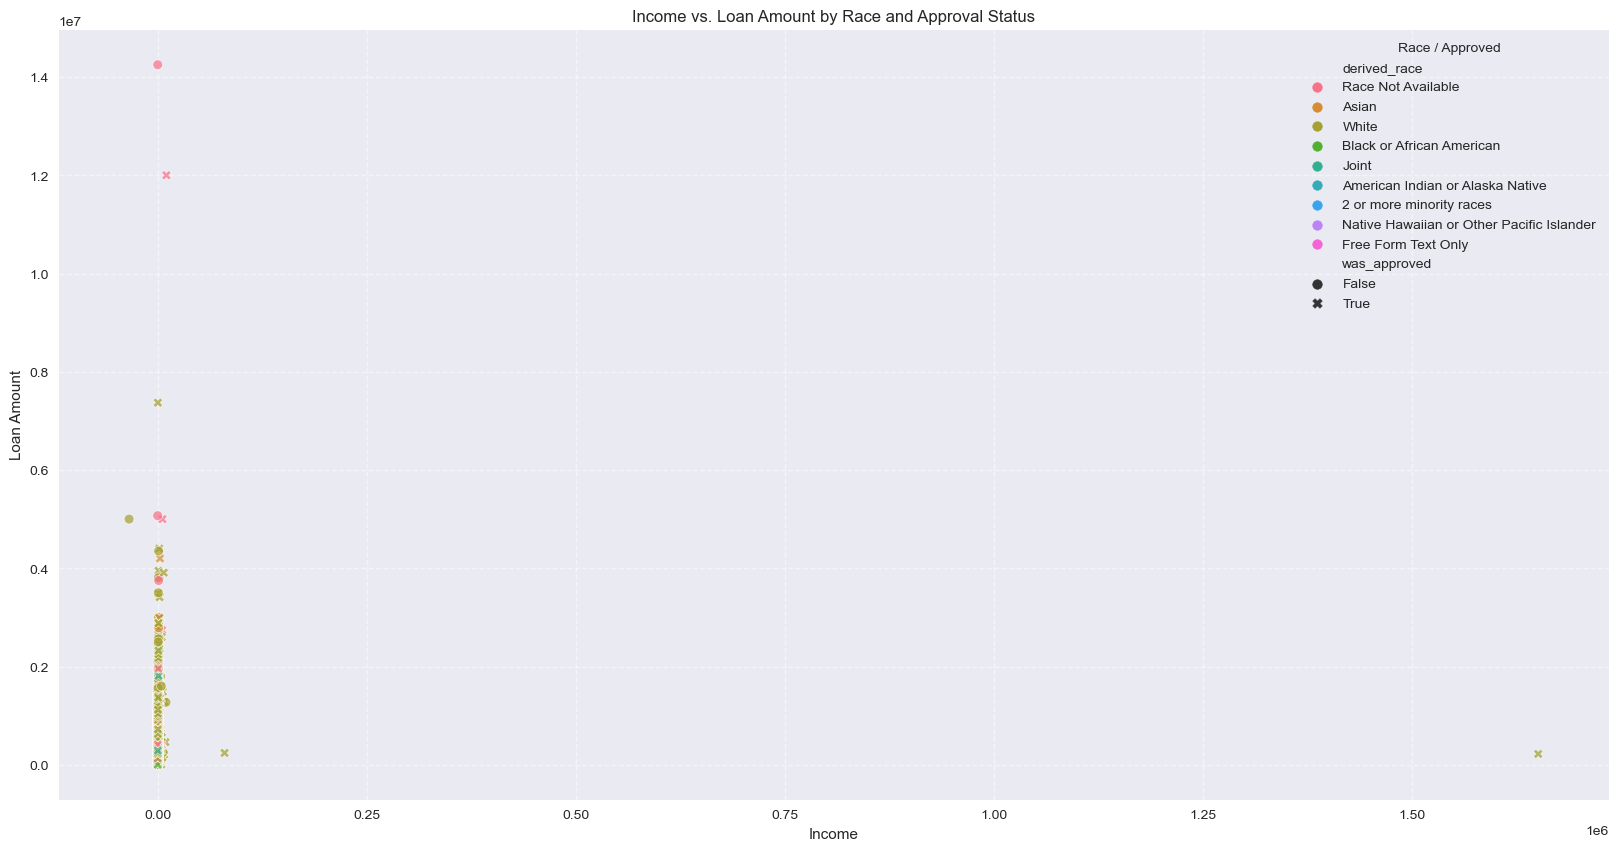

In [13]:
plt.figure(figsize=(20, 10))
sns.scatterplot(x='income', y='loan_amount', hue='derived_race', style='was_approved', data=df, alpha=0.7)
plt.title('Income vs. Loan Amount by Race and Approval Status')
plt.xlabel('Income')
plt.ylabel('Loan Amount')
plt.legend(title='Race / Approved')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


## 5: Approval Rates by Minority Population Percent in Tract  
This histogram shows loan approval distributions relative to the minority population percentages within census tracts. It helps illustrate whether minority-populated areas face disproportionate loan denials.


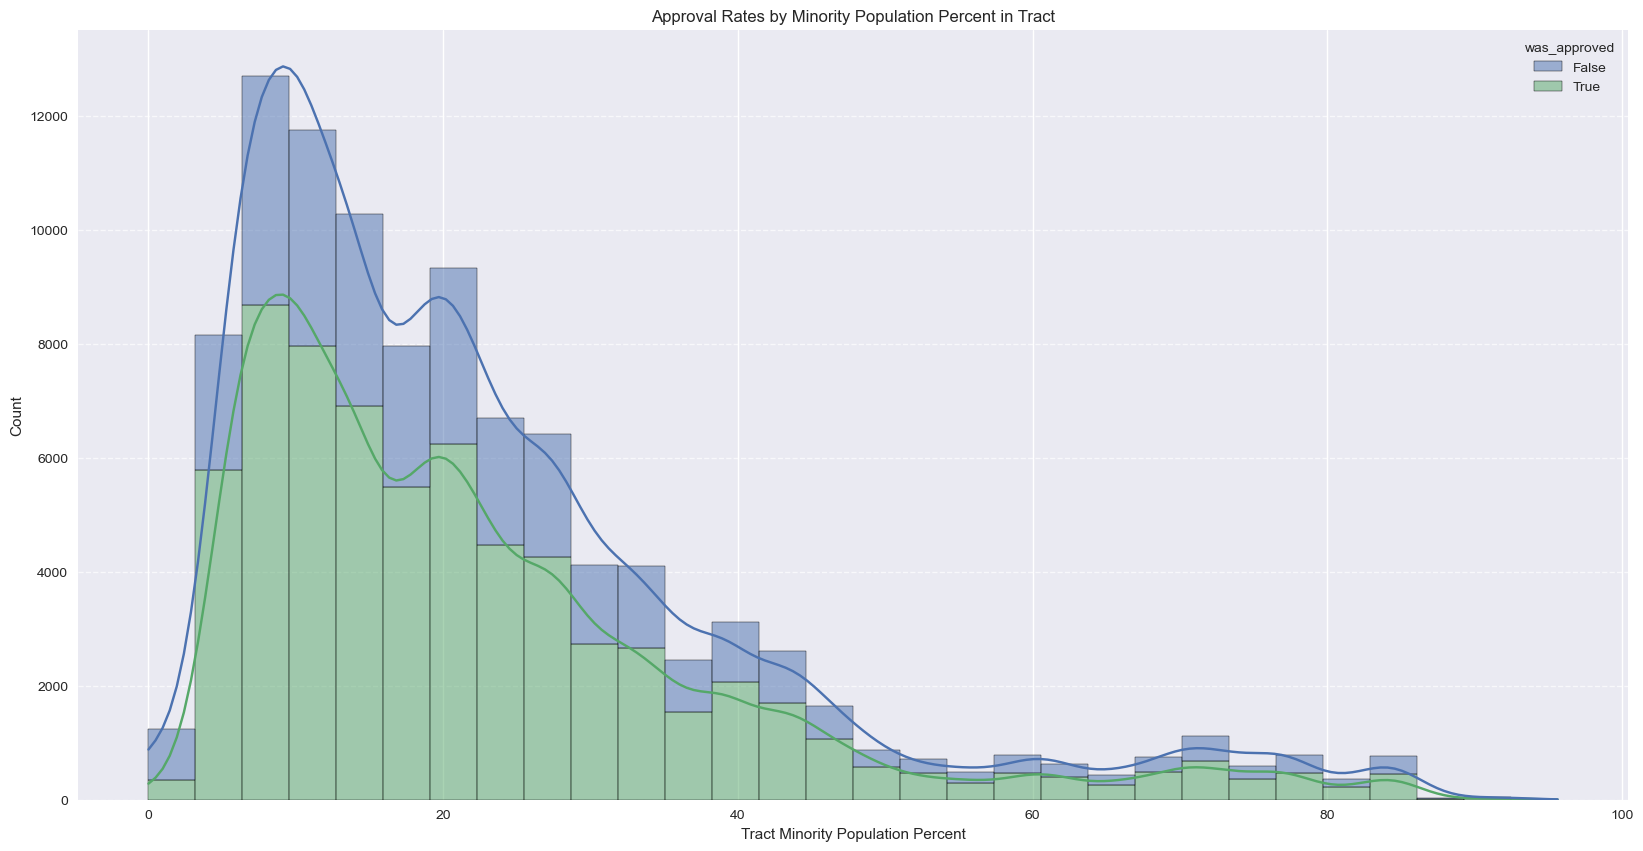

In [15]:
plt.figure(figsize=(20, 10))
sns.histplot(data=df, x='tract_minority_population_percent', hue='was_approved', bins=30, kde=True, multiple='stack')
plt.title('Approval Rates by Minority Population Percent in Tract')
plt.xlabel('Tract Minority Population Percent')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


## 6: Property Value vs. Loan Amount by Approval Status  
This scatterplot compares the relationship between property values and requested loan amounts, colored by loan approval outcomes. It identifies if approval rates vary significantly with property valuations.


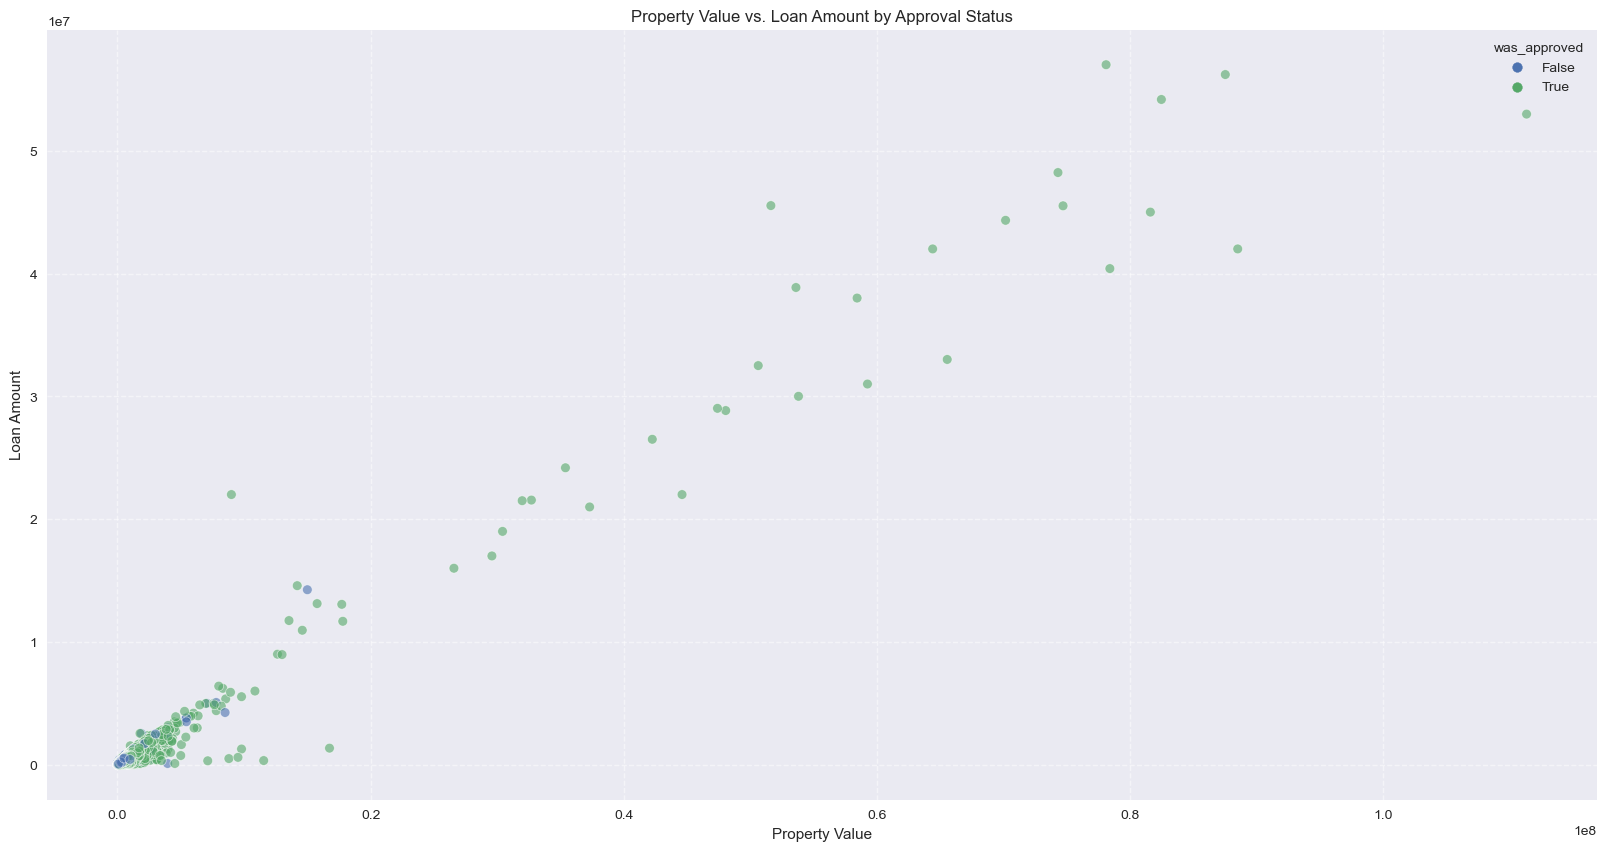

In [17]:
plt.figure(figsize=(20, 10))
sns.scatterplot(data=df, x='property_value', y='loan_amount', hue='was_approved', alpha=0.6)
plt.title('Property Value vs. Loan Amount by Approval Status')
plt.xlabel('Property Value')
plt.ylabel('Loan Amount')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
